# Solar Power Generation Prediction

*This notebook performs an exploratory data analysis, cleans and preprocesses solar power generation and weather sensor data, and then builds a machine learning prediction model using various algoriths like linear, lasso, rigde, gradient boosting, xgboost, decision tree, random forest and support vector machine regression bold text to predict DC power generation based on weather conditions and time-based features.*

##Step 1. Import Required Libraries

First, we'll import all the necessary Python libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

##Step 2. Loading the Data

For  this project we are using Generation and weather data of a solar power plant which is downloaded from UCI Machine Learning Repository. We'll load the `Generation_Data.csv` and `Weather_Sensor_Data.csv` files into pandas DataFrames.

In [3]:
generation = pd.read_csv("Generation_Data.csv")
weather = pd.read_csv("Weather_Sensor_Data.csv")

print("Generation Data Head:")
display(generation.head(), generation.describe(), generation.describe())
print("\nWeather Data Head:")
display(weather.head(), generation.describe(), weather.describe())

Generation Data Head:


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,4.465200e+04,44651.000000,44651.000000,44651.000000,4.465100e+04
mean,4.134908e+06,3263.727596,319.143435,3228.319607,6.935442e+06
std,1.954882e+04,4121.452743,402.659751,3183.090368,4.123869e+05
min,4.135000e+03,0.000000,0.000000,0.000000,6.183645e+06
25%,4.135001e+06,0.000000,0.000000,0.000000,6.447051e+06
50%,4.135001e+06,519.625000,50.275000,2276.375000,7.112610e+06
75%,4.135001e+06,6609.357143,647.241071,6373.000000,7.226198e+06
max,4.135001e+06,14413.428570,1405.300000,9163.000000,7.768021e+06


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,4.465200e+04,44651.000000,44651.000000,44651.000000,4.465100e+04
mean,4.134908e+06,3263.727596,319.143435,3228.319607,6.935442e+06
std,1.954882e+04,4121.452743,402.659751,3183.090368,4.123869e+05
min,4.135000e+03,0.000000,0.000000,0.000000,6.183645e+06
25%,4.135001e+06,0.000000,0.000000,0.000000,6.447051e+06
50%,4.135001e+06,519.625000,50.275000,2276.375000,7.112610e+06
75%,4.135001e+06,6609.357143,647.241071,6373.000000,7.226198e+06
max,4.135001e+06,14413.428570,1405.300000,9163.000000,7.768021e+06



Weather Data Head:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,4.465200e+04,44651.000000,44651.000000,44651.000000,4.465100e+04
mean,4.134908e+06,3263.727596,319.143435,3228.319607,6.935442e+06
std,1.954882e+04,4121.452743,402.659751,3183.090368,4.123869e+05
min,4.135000e+03,0.000000,0.000000,0.000000,6.183645e+06
25%,4.135001e+06,0.000000,0.000000,0.000000,6.447051e+06
50%,4.135001e+06,519.625000,50.275000,2276.375000,7.112610e+06
75%,4.135001e+06,6609.357143,647.241071,6373.000000,7.226198e+06
max,4.135001e+06,14413.428570,1405.300000,9163.000000,7.768021e+06


,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


##Step 3. Initial Data Inspection and Preprocessing

We'll inspect the data types, check for date ranges, and convert date columns to datetime objects. We'll also merge the two datasets.

In [4]:
# Convert 'DATE_TIME' columns to datetime objects
# Using errors='coerce' to handle any parsing issues and dayfirst=True for the 'generation' dataframe
generation['Date_Time'] = pd.to_datetime(generation['DATE_TIME'])
weather['Date_Time'] = pd.to_datetime(weather['DATE_TIME'],)

print("Generation Data Info:")
generation.info()
print("\nWeather Data Info:")
weather.info()

print(f"\nWeather Date Range: {weather['Date_Time'].min()} to {weather['Date_Time'].max()}")
print(f"Generation Date Range: {generation['Date_Time'].min()} to {generation['Date_Time'].max()}")

Generation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44652 entries, 0 to 44651
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    44652 non-null  object        
 1   PLANT_ID     44652 non-null  int64         
 2   SOURCE_KEY   44651 non-null  object        
 3   DC_POWER     44651 non-null  float64       
 4   AC_POWER     44651 non-null  float64       
 5   DAILY_YIELD  44651 non-null  float64       
 6   TOTAL_YIELD  44651 non-null  float64       
 7   Date_Time    44652 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 2.7+ MB

Weather Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   object        
 1

/tmp/ipykernel_2005/3370547744.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation['Date_Time'] = pd.to_datetime(generation['DATE_TIME'])


### Merge DataFrames

Merge the generation and weather dataframes on the `Date_Time` column.

In [5]:
df = pd.merge(generation, weather, on='Date_Time', how='inner')

# Drop redundant columns after merge
df.drop(['DATE_TIME_x', 'PLANT_ID_x', 'SOURCE_KEY_x',
         'DATE_TIME_y', 'PLANT_ID_y', 'SOURCE_KEY_y'], axis=1, inplace=True, errors='ignore')

print("Merged DataFrame Head:")
display(df.head())

Merged DataFrame Head:


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,Date_Time,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,0.0,0.0,0.0,6259559.0,2020-05-15,25.184316,22.857507,0.0
1,0.0,0.0,0.0,6183645.0,2020-05-15,25.184316,22.857507,0.0
2,0.0,0.0,0.0,6987759.0,2020-05-15,25.184316,22.857507,0.0
3,0.0,0.0,0.0,7602960.0,2020-05-15,25.184316,22.857507,0.0
4,0.0,0.0,0.0,7158964.0,2020-05-15,25.184316,22.857507,0.0


##Step 4. Resample Data to 15-Minute Intervals

To ensure consistent time series and handle potential misalignments or missing intervals, we'll resample the data to a 15-minute frequency, taking the mean of values within each interval.

In [6]:
df = df.set_index('Date_Time')
df_15min = df.resample('15min').mean()
df_15min = df_15min.reset_index()

print("Resampled DataFrame Head:")
display(df_15min.head())

Resampled DataFrame Head:


,Date_Time,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,0.0,6.837223e+06,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,0.0,6.837223e+06,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,0.0,6.837223e+06,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,0.0,6.837223e+06,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,0.0,6.852802e+06,24.621525,22.165423,0.0


##Step 5. Handle Missing Values

We'll check for any missing values after resampling and impute them using forward-fill, which is a common method for time-series data.

In [7]:
print("Missing values before imputation:")
print(df_15min.isnull().sum())

df_15min_filled = df_15min.ffill()

print("\nMissing values after forward-fill imputation:")
print(df_15min_filled.isnull().sum())

Missing values before imputation:
Date_Time                0
DC_POWER               105
AC_POWER               105
DAILY_YIELD            105
TOTAL_YIELD            105
AMBIENT_TEMPERATURE    105
MODULE_TEMPERATURE     105
IRRADIATION            105
dtype: int64

Missing values after forward-fill imputation:
Date_Time              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


##Step 5. Data Visualization

## Correlation Matrix
Visualize the correlation between all numerical features and the target variable (DC_POWER) using a heatmap. This helps understand the relationships between variables.

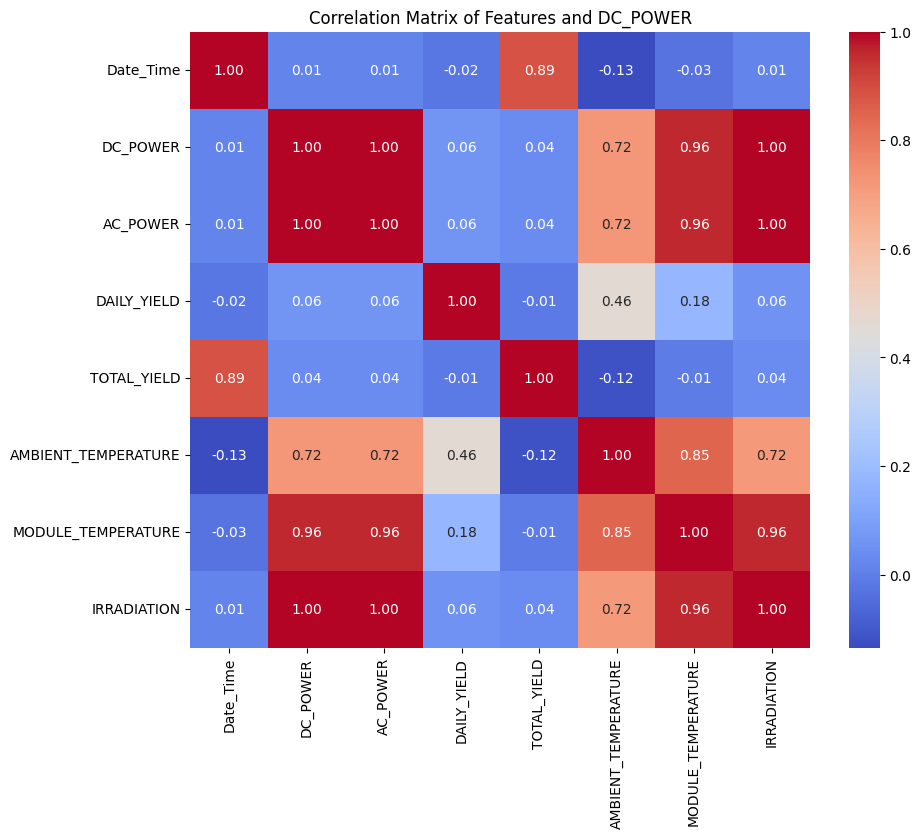

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_15min_filled.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features and DC_POWER")
plt.show()

##Visualization of linearity in data using pairplot

Generating pair plot...


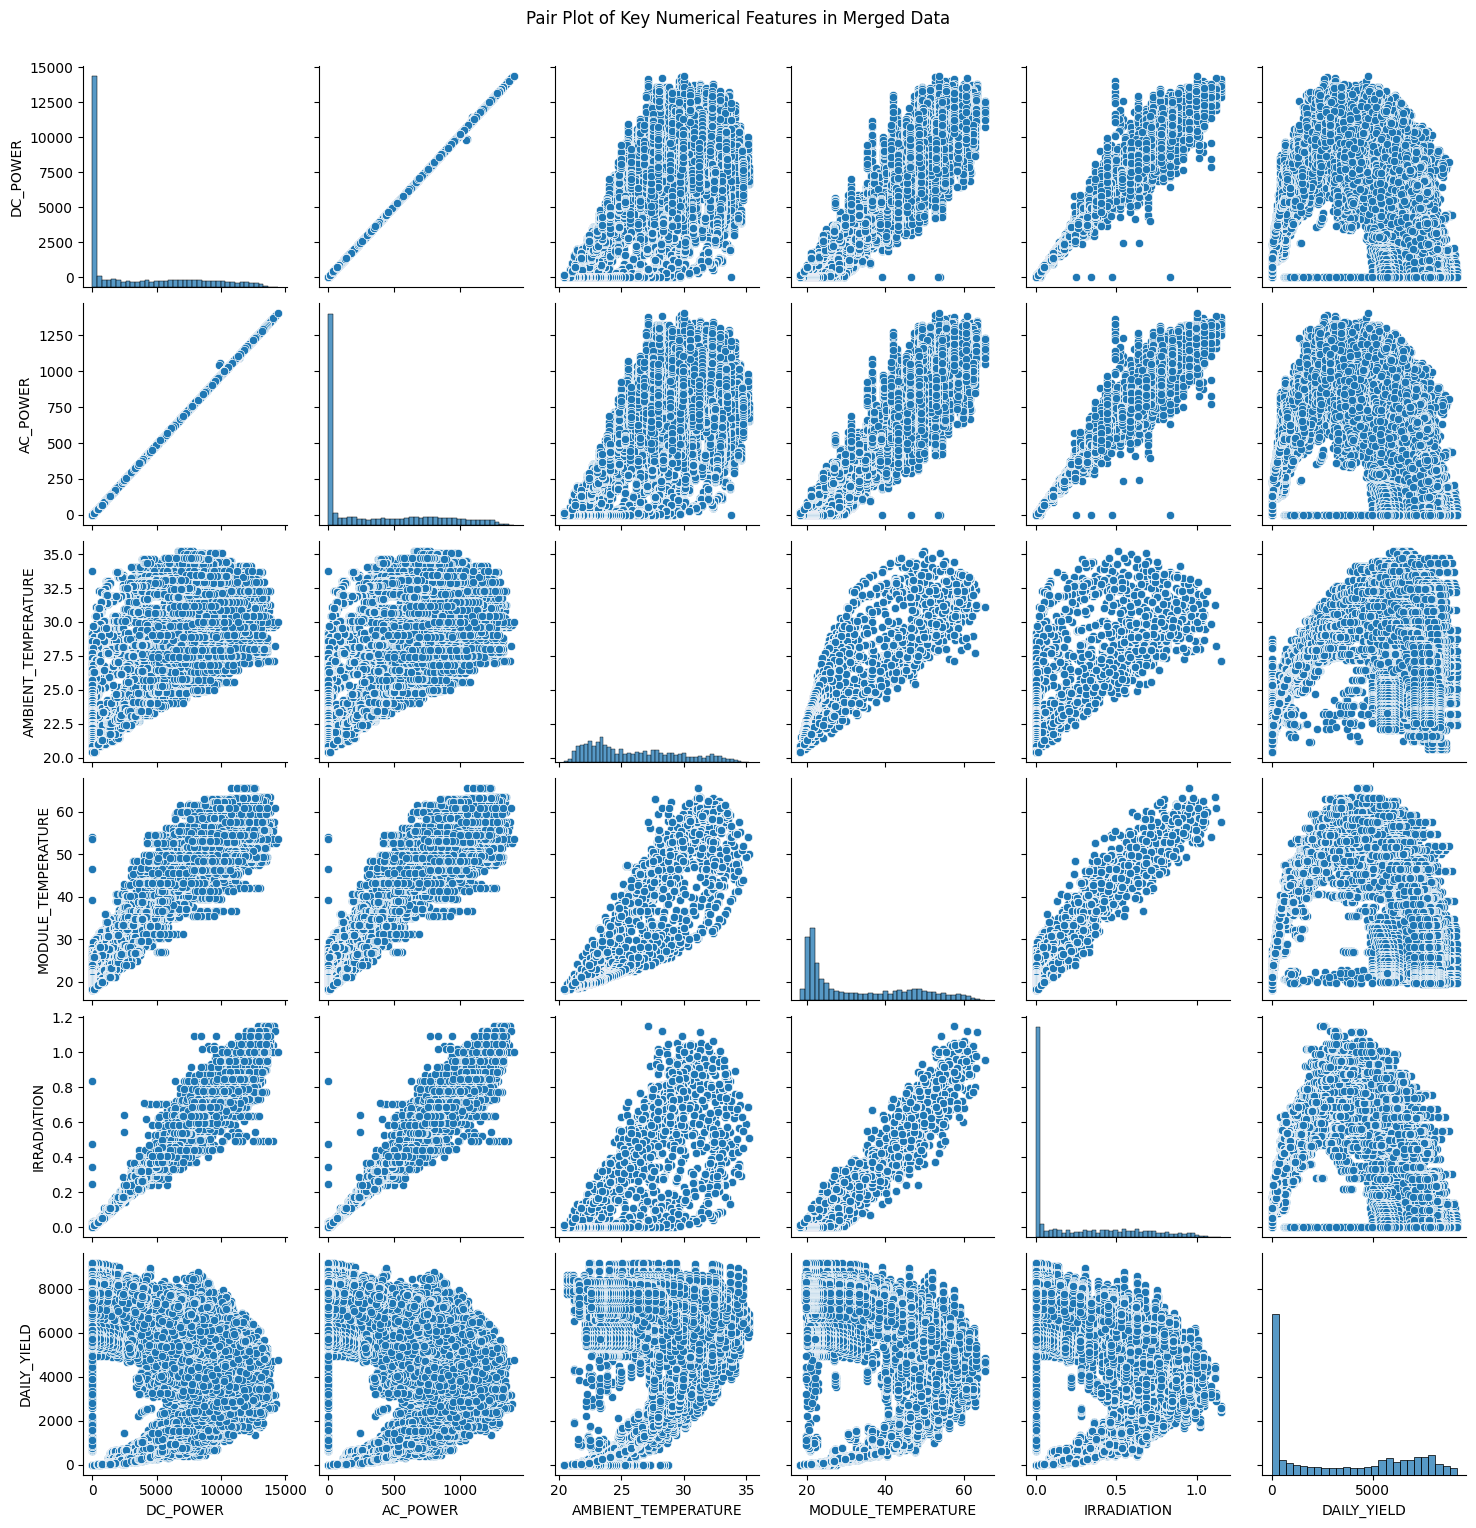

Pair plot generated.


In [9]:


# Generate a pair plot for a subset of numerical columns in merged_df
# Selecting relevant columns to avoid overly large plot and focus on core relationships
# It's good practice to consider columns that are numerical and not purely identifiers

# Let's consider a subset of columns for the pair plot for better visualization
# and to avoid memory issues with too many features.
# We'll focus on the continuous numerical features that are likely to have relationships.
pair_plot_cols = [
    'DC_POWER',
    'AC_POWER',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'DAILY_YIELD'
]

# Ensure selected columns exist in the DataFrame
pair_plot_data = df[pair_plot_cols].dropna()

print("Generating pair plot...")
sns.pairplot(pair_plot_data)
plt.suptitle('Pair Plot of Key Numerical Features in Merged Data', y=1.02) # Add a title to the plot
plt.show()
print("Pair plot generated.")

##Step 6. Feature Engineering

Extract relevant time-based features such as 'hour', 'minute', and 'day of week' from the `Date_Time` column, as these can influence solar power generation.

In [10]:
df_15min_filled['hour'] = df_15min_filled['Date_Time'].dt.hour
df_15min_filled['minute'] = df_15min_filled['Date_Time'].dt.minute
df_15min_filled['day_of_week'] = df_15min_filled['Date_Time'].dt.dayofweek

print("DataFrame with new features (Head):")
display(df_15min_filled.head())

DataFrame with new features (Head):


,Date_Time,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,minute,day_of_week
0,2020-05-15 00:00:00,0.0,0.0,0.0,6.837223e+06,25.184316,22.857507,0.0,0,0,4
1,2020-05-15 00:15:00,0.0,0.0,0.0,6.837223e+06,25.084589,22.761668,0.0,0,15,4
2,2020-05-15 00:30:00,0.0,0.0,0.0,6.837223e+06,24.935753,22.592306,0.0,0,30,4
3,2020-05-15 00:45:00,0.0,0.0,0.0,6.837223e+06,24.846130,22.360852,0.0,0,45,4
4,2020-05-15 01:00:00,0.0,0.0,0.0,6.852802e+06,24.621525,22.165423,0.0,1,0,4


##Step 7. Define Features (X) and Target (y)

We'll define our independent variables (`X`) which are the features we'll use for prediction, and our dependent variable (`y`), which is the `DC_POWER` we want to predict.

In [11]:
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'minute', 'day_of_week']
target = 'DC_POWER'

X = df_15min_filled[features]
y = df_15min_filled[target]

print("Features (X) Head:")
display(X.head())
print("\nTarget (y) Head:")
display(y.head())

Features (X) Head:


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,minute,day_of_week
0,25.184316,22.857507,0.0,0,0,4
1,25.084589,22.761668,0.0,0,15,4
2,24.935753,22.592306,0.0,0,30,4
3,24.846130,22.360852,0.0,0,45,4
4,24.621525,22.165423,0.0,1,0,4



Target (y) Head:


,DC_POWER
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


##Step 8. Outlier Detection (Box Plots)
Use box plots to visually identify potential outliers in the features, which can sometimes affect model performance.

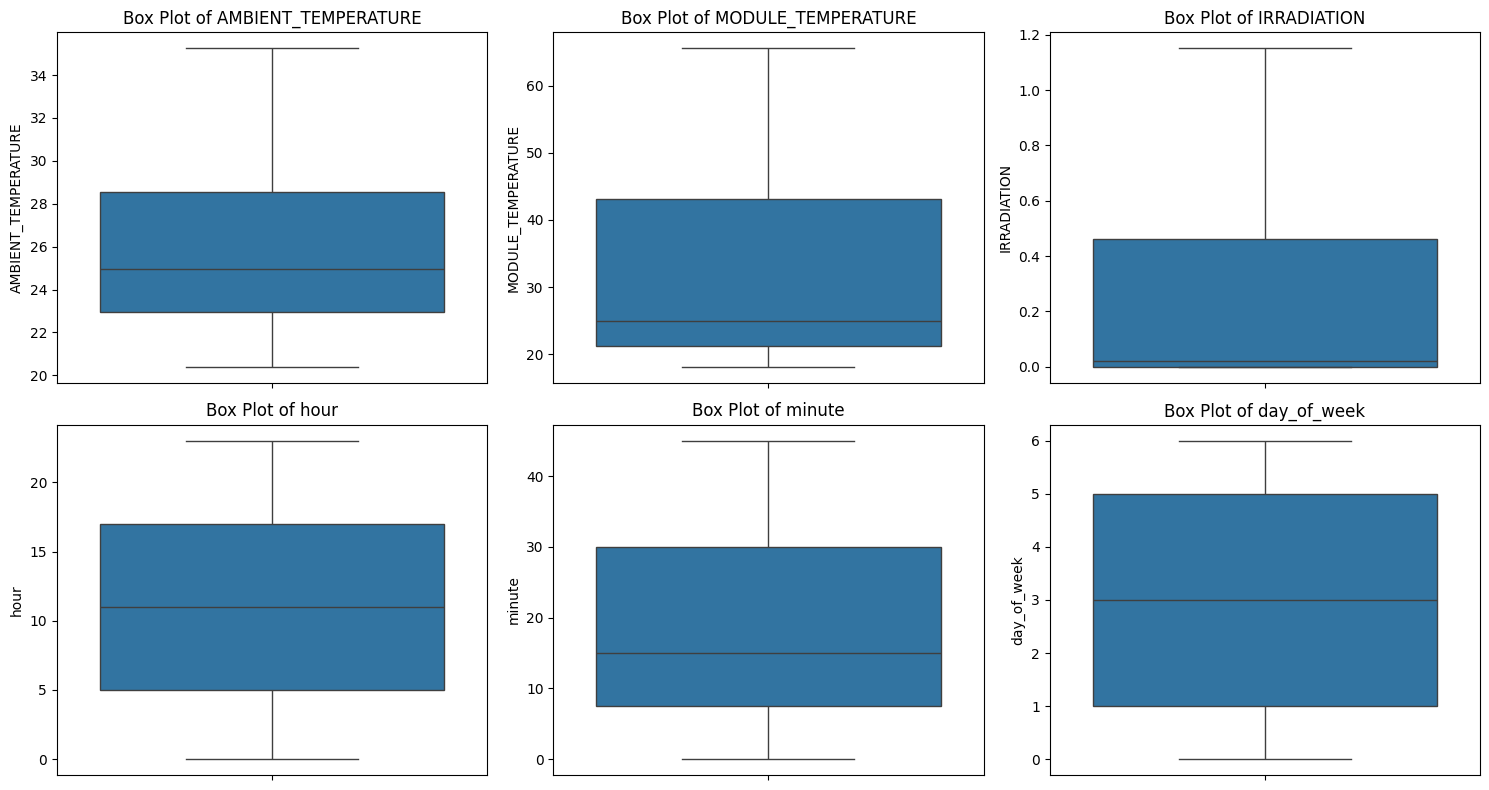

In [12]:
plt.figure(figsize=(15, 8))
num_features = len(features)
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df_15min_filled[col])
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

##Step 9. Histograms and Distribution Analysis
Examine the distribution of individual features and the target variable to understand their characteristics.

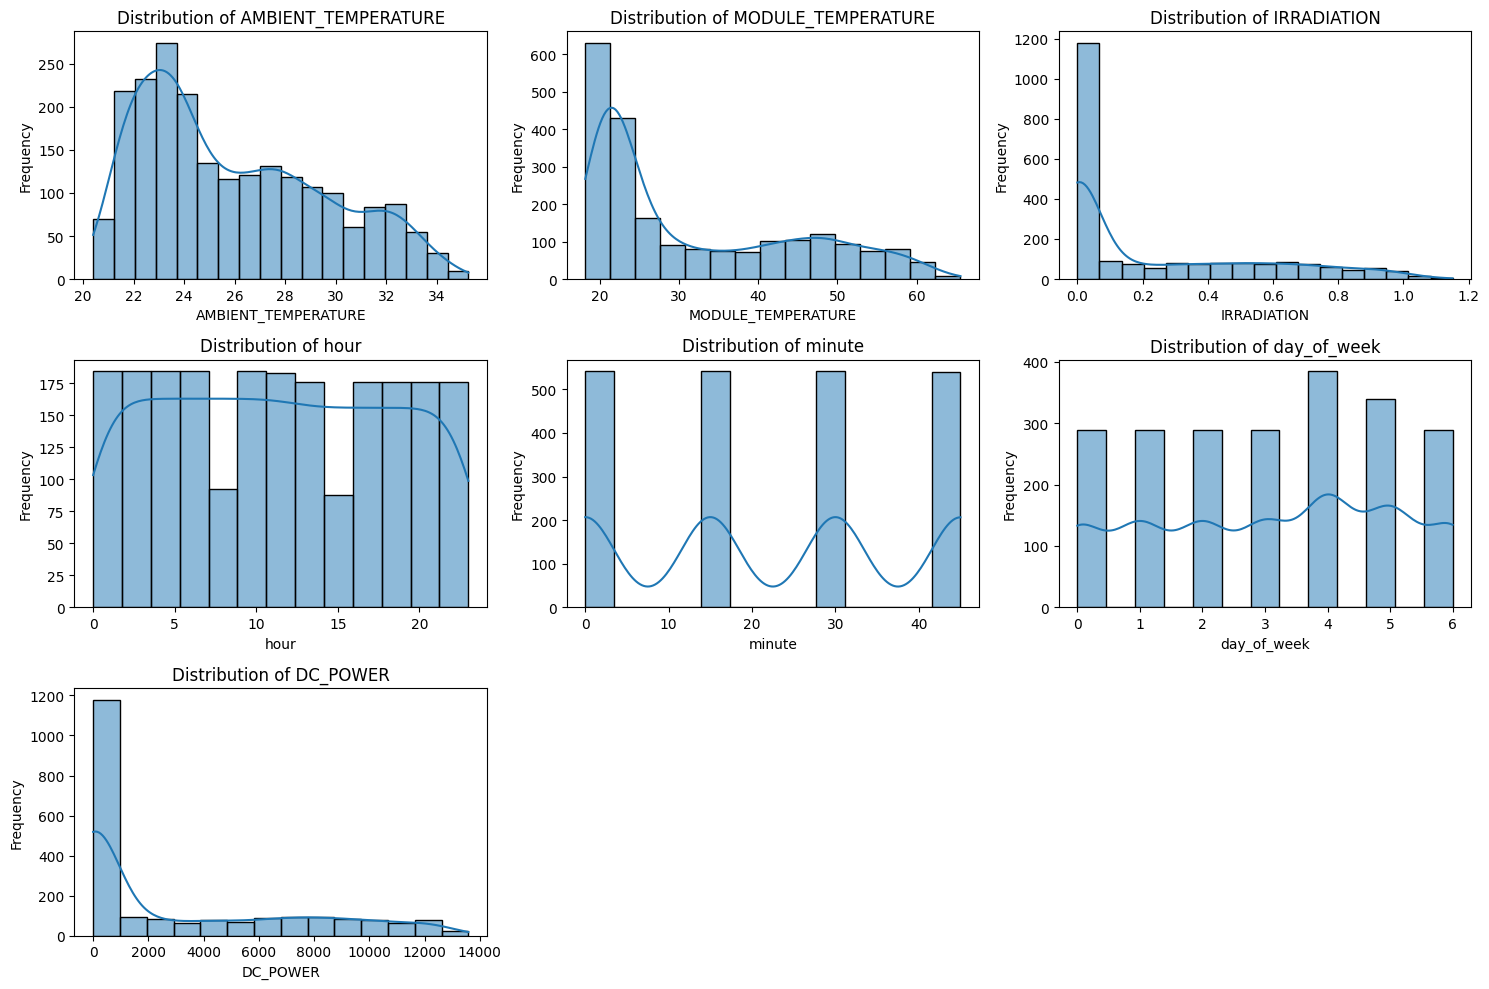

In [13]:
plt.figure(figsize=(15, 10))
num_cols = len(features + [target])
for i, col in enumerate(features + [target]):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_15min_filled[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##Step 10. Split Data into Training and Testing Sets

We'll split our dataset into a training set (80%) and a testing set (20%) to evaluate the model's performance on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} records")
print(f"Testing set size: {len(X_test)} records")

Training set size: 1730 records
Testing set size: 433 records


##Step 11. Data Scaling

Scaling features is often crucial for models that are sensitive to the magnitude of features (e.g., neural networks or models using regularization). We will scale our features using `StandardScaler`, fitting it on the training data and transforming both training and test data.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

print("Scaled Training Features (first 5 rows):")
display(X_train_scaled_df.head())
print("\nScaled Testing Features (first 5 rows):")
display(X_test_scaled_df.head())

Scaled Training Features (first 5 rows):


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,minute,day_of_week
0,0.707532,-0.399794,-0.745625,0.947744,1.342787,-1.069586
1,-0.848327,-0.815510,-0.747839,1.665103,-0.442779,-1.579755
2,1.155474,0.676817,-0.250986,0.373856,0.450004,1.481260
3,1.420550,-0.092924,-0.632748,0.947744,-1.335562,-0.049248
4,0.501235,1.032394,1.530017,-0.343503,1.342787,0.971091



Scaled Testing Features (first 5 rows):


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,minute,day_of_week
0,-1.072966,-0.811104,-0.747839,-1.060862,0.450004,0.971091
1,-0.649424,-0.744466,-0.747839,-1.491278,0.450004,1.481260
2,-1.128428,-0.909790,-0.747839,-0.917391,0.450004,-0.049248
3,1.807478,0.848172,0.274639,0.517328,-0.442779,-1.069586
4,0.254204,0.739450,1.444120,-0.343503,0.450004,0.971091


##Step 12. Train a Linear Regression Model

We'll train a simple `LinearRegression` model using our *scaled* training data.

In [16]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 13. Model Evaluation (Performance and Graphs)

Now, we'll evaluate the performance of our trained model using various metrics and visualizations on the test set.

### R-squared Score

The R-squared value indicates the proportion of variance in the dependent variable that can be predicted from the independent variables.

In [17]:
r_squared = model.score(X_test_scaled, y_test)
print(f"Linear Regression Model R-squared: {r_squared:.4f}")

Linear Regression Model R-squared: 0.9930


###Other Regression Metrics

Calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to quantify prediction errors.

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

NameError: name 'y_pred' is not defined

### Predicted vs Actual Values & Residual Analysis

We'll plot the predicted `DC_POWER` against the actual `DC_POWER` from the test set, and also analyze the distribution of residuals (prediction errors).

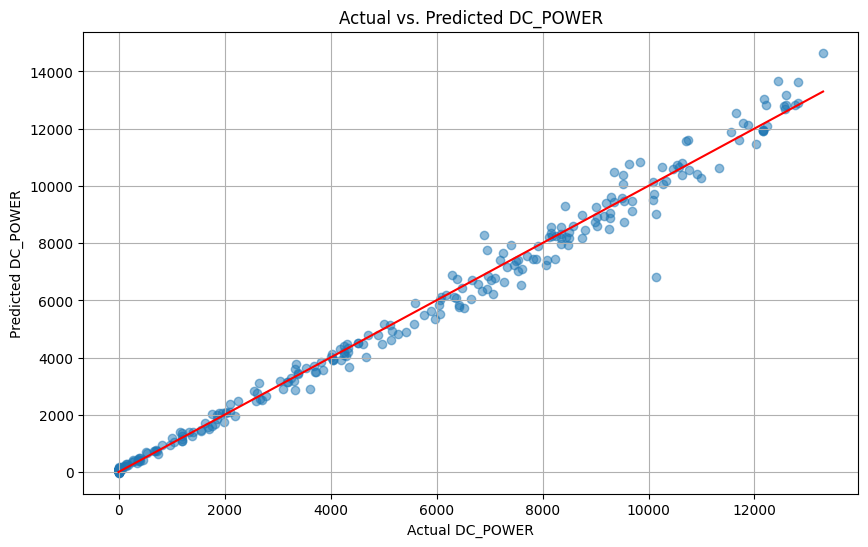

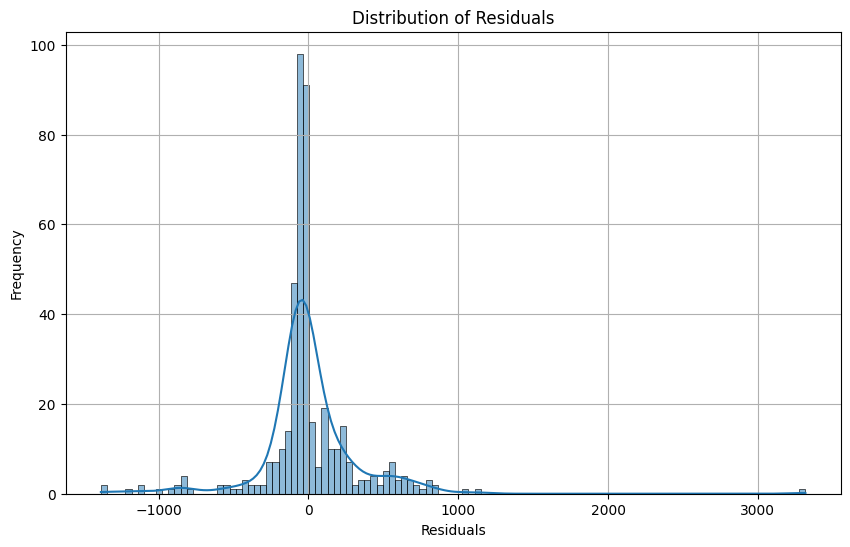

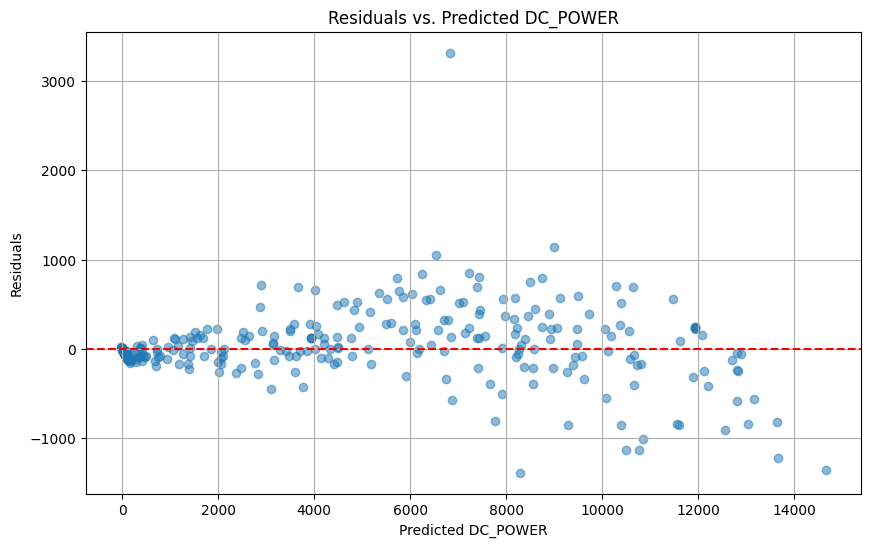

In [19]:
y_pred = model.predict(X_test_scaled)

# Plotting Predicted vs Actual Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual DC_POWER")
plt.ylabel("Predicted DC_POWER")
plt.title("Actual vs. Predicted DC_POWER")
plt.grid(True)
plt.show()

# Plotting Residuals Distribution
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

# Plotting Residuals vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted DC_POWER")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted DC_POWER")
plt.grid(True)
plt.show()

###Step 14. Training other Machine Learning models

In [20]:
def evaluate_model(name, y_true, y_pred):
    print(f"\nModel: {name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred = ridge.predict(X_test_scaled)

evaluate_model("Ridge Regression", y_test, pred)


Model: Ridge Regression
MAE: 187.49416200194872
RMSE: 338.89725831312256
R2 Score: 0.9930406225891852


In [22]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
pred = lasso.predict(X_test_scaled)

evaluate_model("Lasso Regression", y_test, pred)


Model: Lasso Regression
MAE: 187.4165392090478
RMSE: 340.5714838318521
R2 Score: 0.9929716910909436


In [23]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)

evaluate_model("KNN Regressor", y_test, pred)


Model: KNN Regressor
MAE: 311.4418990686323
RMSE: 504.2254163992855
R2 Score: 0.984594218110628


In [24]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)

evaluate_model("Decision Tree", y_test, pred)


Model: Decision Tree
MAE: 169.93726523152822
RMSE: 375.42615953154916
R2 Score: 0.9914594991559696


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

evaluate_model("Random Forest", y_test, pred)


Model: Random Forest
MAE: 134.42572303882704
RMSE: 302.03271471931293
R2 Score: 0.9944723281823501


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
pred = gbr.predict(X_test)

evaluate_model("Gradient Boosting", y_test, pred)


Model: Gradient Boosting
MAE: 126.79000496754654
RMSE: 296.52466008200906
R2 Score: 0.9946721018781294


In [27]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

evaluate_model("XGBoost", y_test, pred)


Model: XGBoost
MAE: 135.7283543034757
RMSE: 323.0621607797676
R2 Score: 0.993675787338215


In [28]:
from sklearn.svm import SVR

svr = SVR(kernel='linear')
svr.fit(X_train_scaled, y_train)
pred = svr.predict(X_test_scaled)

evaluate_model("SVR", y_test, pred)


Model: SVR
MAE: 1284.2598977167613
RMSE: 1890.9030313369963
R2 Score: 0.7833429654649757


##Step 15. Comparison of accuracy results of different ML models.

In [29]:
results = {
    "Model": [],
    "R2": []
}

models = {
    "Linear Regression": model,
    "Ridge": ridge,
    "Lasso": lasso,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "XGBoost": xgb,
    "SVR": svr
}

for name, model in models.items():
    if name in ["Linear Regression","Ridge","Lasso","KNN","SVR"]:
        pred = model.predict(X_test_scaled)
    else:
        pred = model.predict(X_test)

    results["Model"].append(name)
    results["R2"].append(r2_score(y_test, pred))

pd.DataFrame(results).sort_values(by="R2", ascending=False)

,Model,R2
6,Gradient Boosting,0.994672
5,Random Forest,0.994472
7,XGBoost,0.993676
1,Ridge,0.993041
2,Lasso,0.992972
0,Linear Regression,0.992971
4,Decision Tree,0.991459
3,KNN,0.984594
8,SVR,0.783343


/tmp/ipykernel_2005/3811323722.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')


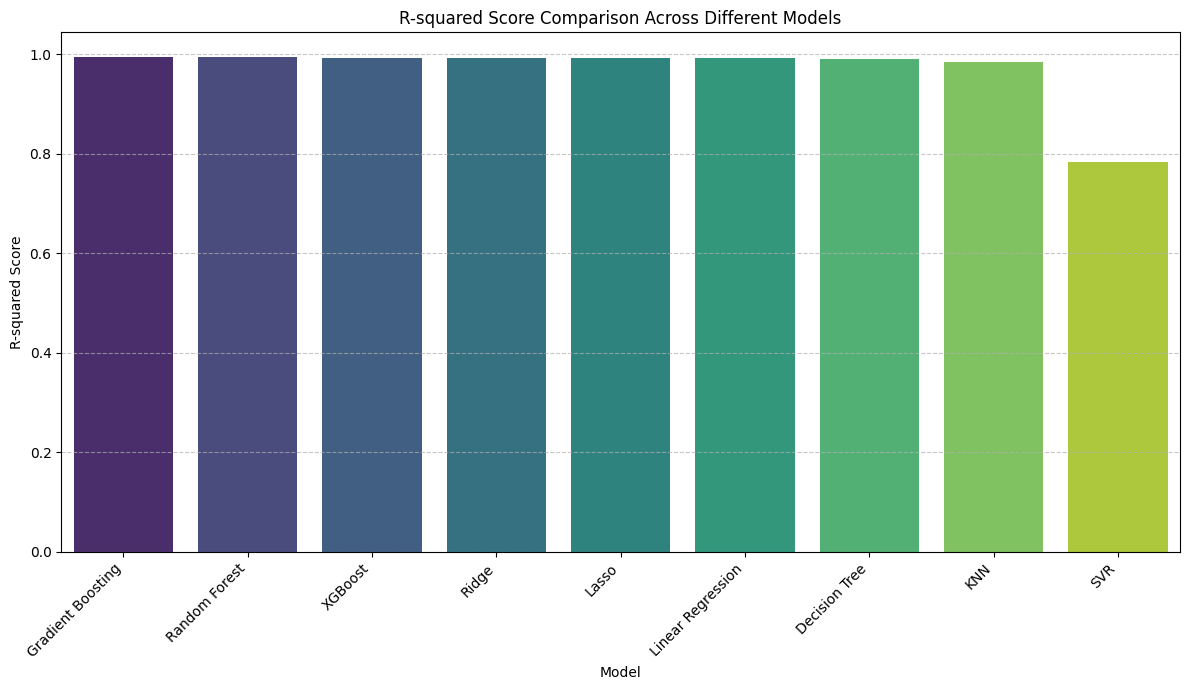

In [30]:
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')
plt.title('R-squared Score Comparison Across Different Models')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()